# 1. Import Libraries

In [1]:
import os
import sys
import gc
import json
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from datetime import datetime
from scipy import stats


# 2. File Paths

In [2]:
# Menambahkan folder Scripts ke path agar model.py bisa diimport
scripts_path = os.path.abspath(os.path.join('..', 'Scripts'))
if scripts_path not in sys.path:
    sys.path.append(scripts_path)

# Path folder data
data_dir             = os.path.abspath(os.path.join('..', 'Data', 'TrainTest'))
hyperparameter_dir   = os.path.abspath(os.path.join('..', 'Data', 'HyperParameters'))
cv_output_dir        = os.path.abspath(os.path.join('..', 'Data', 'CrossValidation'))

# Buat folder CrossValidation jika belum ada
os.makedirs(cv_output_dir, exist_ok=True)

print(f"[INFO] Scripts path  : {scripts_path}")
print(f"[INFO] Data dir      : {data_dir}")
print(f"[INFO] CV output dir : {cv_output_dir}")

[INFO] Scripts path  : c:\Users\USER\Documents\Folder-Proposal\Programs\Scripts
[INFO] Data dir      : c:\Users\USER\Documents\Folder-Proposal\Programs\Data\TrainTest
[INFO] CV output dir : c:\Users\USER\Documents\Folder-Proposal\Programs\Data\CrossValidation


# 3. Import Model

In [3]:
from model_enhanced import Encoder, Decoder, VAE, RSVD, KLAnnealingCallback, CyclicalKLAnnealingCallback

# 4. Load Data & Hyperparameters

## 1 Load Normalized Matrix
Cross Validation membutuhkan data **sebelum di-split** agar setiap fold
mendapat pembagian yang adil dan terkontrol. File ini disimpan di langkah
terakhir DataPreprocessing.ipynb.

In [4]:
# Load matriks rating yang sudah dinormalisasi (0-1), belum di-split
normalized_matrix_path = os.path.join(data_dir, 'normalized_matrix.npy')

try:
    normalized_matrix = np.load(normalized_matrix_path).astype(np.float32)
    num_users, num_items = normalized_matrix.shape
    print(f"[SUCCESS] Normalized matrix berhasil dimuat.")
    print(f"          Dimensi: {num_users} Users x {num_items} Items")
except FileNotFoundError:
    print("[ERROR] File 'normalized_matrix.npy' tidak ditemukan.")
    print("        Pastikan kamu sudah menjalankan DataPreprocessing.ipynb")
    print("        dan sudah menambahkan baris penyimpanan normalized_matrix.")

[SUCCESS] Normalized matrix berhasil dimuat.
          Dimensi: 943 Users x 1682 Items


## 2 Load Best Hyperparameters
Gunakan hyperparameter terbaik dari hasil tuning. Tidak perlu tuning ulang
di setiap fold karena akan sangat memakan waktu dan bukan standar akademis.

In [5]:
# Load hyperparameter terbaik VAE
vae_progress_path = os.path.join(hyperparameter_dir, 'tuning_progress_vae_enh.json')
with open(vae_progress_path, 'r') as f:
    best_vae_params = json.load(f)['best_params']

# Load hyperparameter terbaik RSVD
rsvd_progress_path = os.path.join(hyperparameter_dir, 'tuning_progress_rsvd.json')
with open(rsvd_progress_path, 'r') as f:
    best_rsvd_params = json.load(f)['best_params']

print(f"[INFO] Best VAE params  : {best_vae_params}")
print(f"[INFO] Best RSVD params : {best_rsvd_params}")

[INFO] Best VAE params  : {'latent_dim': 200, 'learning_rate': 0.005, 'batch_size': 128, 'dropout_rate': 0.4, 'beta': 0.1, 'cycle_epochs': 15, 'hidden_dims': [512, 256, 128]}
[INFO] Best RSVD params : {'n_factors': 10, 'learning_rate': 0.005, 'lambda_reg': 0.001}


# 5. Configure Cross Validation

In [6]:
# ============================================================
# KONFIGURASI UTAMA — ubah nilai di sini jika perlu
# ============================================================

# Jumlah fold untuk K-Fold Cross Validation
N_FOLDS = 10

# Epoch untuk setiap fold (lebih sedikit dari Training final karena tujuannya konsistensi)
CV_VAE_EPOCHS  = 50
CV_RSVD_EPOCHS = 30

# Skala rating asli untuk denormalisasi hasil prediksi
MAX_RATING = 5.0

# Seed acak untuk memastikan hasil dapat direplikasi
RANDOM_SEED = 42

print(f"[INFO] Konfigurasi CV:")
print(f"       N_FOLDS        = {N_FOLDS}")
print(f"       CV_VAE_EPOCHS  = {CV_VAE_EPOCHS}")
print(f"       CV_RSVD_EPOCHS = {CV_RSVD_EPOCHS}")
print(f"       MAX_RATING     = {MAX_RATING}")
print(f"       RANDOM_SEED    = {RANDOM_SEED}")

[INFO] Konfigurasi CV:
       N_FOLDS        = 10
       CV_VAE_EPOCHS  = 50
       CV_RSVD_EPOCHS = 30
       MAX_RATING     = 5.0
       RANDOM_SEED    = 42


# 6. Create Fold Splits

## 1 All Ratings Coordinates

In [7]:
# Ambil koordinat (baris, kolom) dari semua rating yang ada nilainya (> 0)
# Ini adalah 100.000 pasang koordinat yang merepresentasikan setiap rating
all_rows, all_cols = np.nonzero(normalized_matrix)

total_ratings = len(all_rows)
print(f"[INFO] Total rating yang tersedia : {total_ratings:,}")

[INFO] Total rating yang tersedia : 100,000


## 2 Randomize and Divide into K-Fold

In [8]:
# Set seed untuk reproduksibilitas
np.random.seed(RANDOM_SEED)

# Acak urutan semua indeks rating
shuffled_indices = np.random.permutation(total_ratings)

# Bagi indeks yang sudah diacak menjadi N_FOLDS bagian yang (hampir) sama besar
# np.array_split otomatis menangani jika total tidak habis dibagi
fold_index_groups = np.array_split(shuffled_indices, N_FOLDS)

# Tampilkan ukuran setiap fold untuk verifikasi
print(f"[INFO] Pembagian {N_FOLDS} fold:")
for fold_num, fold_indices in enumerate(fold_index_groups):
    print(f"       Fold {fold_num + 1}: {len(fold_indices):,} rating sebagai data test")

[INFO] Pembagian 10 fold:
       Fold 1: 10,000 rating sebagai data test
       Fold 2: 10,000 rating sebagai data test
       Fold 3: 10,000 rating sebagai data test
       Fold 4: 10,000 rating sebagai data test
       Fold 5: 10,000 rating sebagai data test
       Fold 6: 10,000 rating sebagai data test
       Fold 7: 10,000 rating sebagai data test
       Fold 8: 10,000 rating sebagai data test
       Fold 9: 10,000 rating sebagai data test
       Fold 10: 10,000 rating sebagai data test


# 7. Helper Functions

## 1 Train/Test Matrix per Fold

In [9]:
def create_fold_matrices(normalized_matrix, all_rows, all_cols, test_fold_indices):
    """
    Membuat matriks train dan test untuk satu fold tertentu.

    Cara kerja:
    - Train matrix = normalized_matrix dengan rating test di-set ke 0
    - Test matrix  = matriks kosong yang hanya berisi rating pada fold test

    Args:
        normalized_matrix  : Matriks rating penuh (943 x 1682), sudah dinormalisasi
        all_rows           : Array semua indeks baris dari rating yang ada
        all_cols           : Array semua indeks kolom dari rating yang ada
        test_fold_indices  : Indeks dari fold_index_groups yang jadi data test fold ini

    Returns:
        train_matrix : np.ndarray (943 x 1682)
        test_matrix  : np.ndarray (943 x 1682)
        test_indices : tuple (rows, cols) koordinat test untuk filtering prediksi
    """
    # Ambil baris dan kolom koordinat untuk fold test ini
    test_rows = all_rows[test_fold_indices]
    test_cols = all_cols[test_fold_indices]

    # Buat train matrix: copy penuh, lalu hapus rating yang masuk fold test
    train_matrix = normalized_matrix.copy()
    train_matrix[test_rows, test_cols] = 0.0

    # Buat test matrix: mulai dari nol, isi hanya rating fold test
    test_matrix = np.zeros(normalized_matrix.shape, dtype=np.float32)
    test_matrix[test_rows, test_cols] = normalized_matrix[test_rows, test_cols]

    return train_matrix, test_matrix, (test_rows, test_cols)

## 2 Training VAE per Fold

In [10]:
def train_vae_fold(train_matrix, vae_params, num_items, epochs, kl_cycle_epochs=25):
    """
    Melatih VAE untuk satu fold dan mengembalikan prediksi rekonstruksi.

    Fungsi ini menggunakan KL Annealing untuk menaikkan bobot beta secara
    bertahap dari 0 ke nilai target selama kl_annealing_epochs pertama.
    Pendekatan ini mencegah posterior collapse pada ruang laten sehingga
    menghasilkan representasi yang lebih informatif.

    Fungsi ini terisolasi (semua objek model dihapus di akhir) untuk
    mencegah memory leak antar fold.

    Args:
        train_matrix        : np.ndarray matriks training fold ini
        vae_params          : dict hyperparameter terbaik VAE
        num_items           : int jumlah kolom (film) untuk dimensi output decoder
        epochs              : int jumlah epoch training untuk CV (lebih sedikit dari final)
        kl_cycle_epochs     : int jumlah epoch per siklus cyclical annealing.
                              Default 25.

    Returns:
        pred_matrix : np.ndarray hasil rekonstruksi VAE (943 x 1682), skala 0-1
    """
    # Bersihkan sesi TensorFlow sebelum membuat model baru
    tf.keras.backend.clear_session()

    # Ubah data ke TensorFlow constant agar tidak ada duplikasi memori
    train_tf = tf.constant(train_matrix, dtype=tf.float32)

    # Bangun arsitektur VAE dengan hyperparameter terbaik
    encoder = Encoder(
        hidden_dims=vae_params['hidden_dims'],
        latent_dim=vae_params['latent_dim'],
        dropout_rate=vae_params['dropout_rate']
    )
    decoder = Decoder(
        hidden_dims=vae_params['hidden_dims'][::-1],
        output_dim=num_items
    )

    # Inisialisasi VAE dengan beta=0.0 agar KL annealing mulai dari nol
    vae_model = VAE(encoder, decoder, beta=0.0, input_dropout_rate=0.5)

    # Inisialisasi bobot dengan melewatkan 1 baris data
    _ = vae_model(train_tf[:1])

    # Kompilasi dengan optimizer Adam
    # Gradient clipping konsisten dengan saat hyperparameter tuning
    optimizer = tf.keras.optimizers.Adam(
        learning_rate = vae_params['learning_rate'],
        clipnorm      = 1.0
    )
    vae_model.compile(optimizer=optimizer, run_eagerly=True)

    # Callback KL annealing: naikkan beta dari 0 ke vae_params['beta'] secara linear
    kl_annealing = CyclicalKLAnnealingCallback(
        beta_target=vae_params['beta'],
        cycle_epochs=vae_params['cycle_epochs']
    )

    # Latih model dengan KL annealing (verbose=0 agar output tidak terlalu panjang)
    vae_model.fit(
        train_tf, train_tf,
        epochs=epochs,
        batch_size=vae_params['batch_size'],
        callbacks=[kl_annealing],
        verbose=0
    )

    # Ekstrak ruang laten (z_mean) lalu rekonstruksi dengan decoder
    z_mean, _ = vae_model.encoder.predict(train_tf, verbose=0)
    pred_matrix = vae_model.decoder.predict(z_mean, verbose=0)

    # Bersihkan semua objek model dari memori
    del encoder, decoder, vae_model, optimizer, train_tf, z_mean, _, kl_annealing
    gc.collect()
    tf.keras.backend.clear_session()

    return pred_matrix

## 3 Training RSVD per Fold

In [11]:
def train_rsvd_fold(train_matrix, rsvd_params, epochs):
    """
    Melatih RSVD untuk satu fold dan mengembalikan matriks prediksi penuh.

    Args:
        train_matrix : np.ndarray matriks training fold ini
        rsvd_params  : dict hyperparameter terbaik RSVD
        epochs       : int jumlah epoch training untuk CV

    Returns:
        pred_matrix : np.ndarray prediksi rating penuh (943 x 1682), skala 0-1
    """
    # Inisialisasi model RSVD dengan hyperparameter terbaik
    rsvd_model = RSVD(
        n_factors=rsvd_params['n_factors'],
        learning_rate=rsvd_params['learning_rate'],
        lambda_reg=rsvd_params['lambda_reg'],
        epochs=epochs
    )

    # Latih model dengan data training fold ini
    rsvd_model.fit(train_matrix)

    # Rekonstruksi prediksi penuh: bias + interaksi laten
    bias_matrix  = float(rsvd_model.mu) + rsvd_model.b_u[:, np.newaxis] + rsvd_model.b_i[np.newaxis, :]
    latent_matrix = np.dot(np.dot(rsvd_model.U, rsvd_model.Sigma), rsvd_model.V.T)
    pred_matrix  = bias_matrix + latent_matrix

    # Bersihkan objek model dari memori
    del rsvd_model, bias_matrix, latent_matrix
    gc.collect()

    return pred_matrix

## 4 Find Best Ensemble Weight

In [12]:
def find_best_ensemble_alpha(pred_vae_clipped, pred_rsvd_clipped, actual_values):
    """
    Mencari bobot alpha terbaik untuk ensemble VAE dan RSVD.

    Formula ensemble: pred = (alpha * VAE) + ((1 - alpha) * RSVD)
    Alpha dicari dari 0.00 hingga 1.00 dengan langkah 0.01.

    Args:
        pred_vae_clipped  : np.ndarray prediksi VAE yang sudah di-clip ke skala asli
        pred_rsvd_clipped : np.ndarray prediksi RSVD yang sudah di-clip ke skala asli
        actual_values     : np.ndarray nilai rating asli dari test set

    Returns:
        best_alpha : float bobot terbaik untuk VAE
        best_rmse  : float nilai RMSE terbaik yang ditemukan
    """
    best_alpha = 0.0
    best_rmse  = float('inf')

    # Coba setiap nilai alpha dari 0% hingga 100% dengan langkah 1%
    for alpha in np.linspace(0, 1, 101):
        beta = 1.0 - alpha
        pred_ensemble = np.clip((alpha * pred_vae_clipped) + (beta * pred_rsvd_clipped), 1.0, MAX_RATING)
        rmse = np.sqrt(np.mean(np.square(actual_values - pred_ensemble)))

        if rmse < best_rmse:
            best_rmse  = rmse
            best_alpha = alpha

    return best_alpha, best_rmse

## 5 Calculate Evaluation Metrics

In [13]:
def calculate_metrics(y_true, y_pred):
    """
    Menghitung tiga metrik evaluasi regresi sekaligus.

    Args:
        y_true : np.ndarray nilai rating asli
        y_pred : np.ndarray nilai rating yang diprediksi

    Returns:
        mse  : float Mean Squared Error
        rmse : float Root Mean Squared Error
        mae  : float Mean Absolute Error
    """
    mse  = np.mean(np.square(y_true - y_pred))
    rmse = np.sqrt(mse)
    mae  = np.mean(np.abs(y_true - y_pred))
    return mse, rmse, mae

# 8. Execute K-Fold Cross Validation

Setiap fold menjalankan pipeline berikut:
1. Buat train/test matrix untuk fold ini
2. Latih VAE → ambil prediksi → denormalisasi → clip
3. Latih RSVD → ambil prediksi → denormalisasi → clip
4. Cari alpha ensemble terbaik
5. Hitung MSE / RMSE / MAE untuk ketiga model
6. Simpan hasil fold ke list

In [14]:
# Tempat penampung hasil semua fold
# Setiap key menyimpan list dengan panjang N_FOLDS
cv_results = {
    'fold'           : [],
    'vae_mse'        : [], 'vae_rmse'        : [], 'vae_mae'        : [],
    'rsvd_mse'       : [], 'rsvd_rmse'       : [], 'rsvd_mae'       : [],
    'hybrid_mse'     : [], 'hybrid_rmse'     : [], 'hybrid_mae'     : [],
    'best_alpha'     : [],
    'test_size'      : []
}

# ============================================================
# LOOP UTAMA CROSS VALIDATION
# ============================================================
for fold_idx, test_fold_indices in enumerate(fold_index_groups):
    fold_num = fold_idx + 1
    print(f"\n{'='*60}")
    print(f"  FOLD {fold_num} / {N_FOLDS}")
    print(f"{'='*60}")

    # ----------------------------------------------------------
    # LANGKAH 1: Buat matriks train dan test untuk fold ini
    # ----------------------------------------------------------
    train_matrix, test_matrix, test_indices = create_fold_matrices(
        normalized_matrix, all_rows, all_cols, test_fold_indices
    )

    # Ambil nilai aktual dari test set (sudah dinormalisasi), lalu denormalisasi
    actual_values_norm = test_matrix[test_indices]
    actual_values      = actual_values_norm * MAX_RATING
    print(f"  [INFO] Train size: {int(np.sum(train_matrix > 0)):,} ratings | Test size: {len(actual_values):,} ratings")

    # ----------------------------------------------------------
    # LANGKAH 2: Training dan Prediksi VAE
    # ----------------------------------------------------------
    print(f"  [VAE] Mulai training ({CV_VAE_EPOCHS} epoch)...")
    pred_vae_full = train_vae_fold(
        train_matrix, best_vae_params, num_items, CV_VAE_EPOCHS
    )

    # Filter hanya indeks test → denormalisasi → clip ke rentang 1–5
    pred_vae_test = pred_vae_full[test_indices] * MAX_RATING
    pred_vae_clipped = np.clip(pred_vae_test, 1.0, MAX_RATING)
    del pred_vae_full
    print(f"  [VAE] Selesai.")

    # ----------------------------------------------------------
    # LANGKAH 3: Training dan Prediksi RSVD
    # ----------------------------------------------------------
    print(f"  [RSVD] Mulai training ({CV_RSVD_EPOCHS} epoch)...")
    pred_rsvd_full = train_rsvd_fold(
        train_matrix, best_rsvd_params, CV_RSVD_EPOCHS
    )

    # Filter hanya indeks test → denormalisasi → clip ke rentang 1–5
    pred_rsvd_test = pred_rsvd_full[test_indices] * MAX_RATING
    pred_rsvd_clipped = np.clip(pred_rsvd_test, 1.0, MAX_RATING)
    del pred_rsvd_full
    print(f"  [RSVD] Selesai.")

    # ----------------------------------------------------------
    # LANGKAH 4: Cari bobot ensemble terbaik untuk fold ini
    # ----------------------------------------------------------
    print(f"  [ENSEMBLE] Mencari alpha terbaik...")
    best_alpha, _ = find_best_ensemble_alpha(
        pred_vae_clipped, pred_rsvd_clipped, actual_values
    )
    best_beta = 1.0 - best_alpha

    # Hitung prediksi ensemble dengan bobot terbaik
    pred_hybrid_clipped = np.clip(
        (best_alpha * pred_vae_clipped) + (best_beta * pred_rsvd_clipped),
        1.0, MAX_RATING
    )
    print(f"  [ENSEMBLE] Alpha terbaik fold {fold_num}: VAE={best_alpha:.2f}, RSVD={best_beta:.2f}")

    # ----------------------------------------------------------
    # LANGKAH 5: Hitung metrik evaluasi
    # ----------------------------------------------------------
    mse_v, rmse_v, mae_v = calculate_metrics(actual_values, pred_vae_clipped)
    mse_r, rmse_r, mae_r = calculate_metrics(actual_values, pred_rsvd_clipped)
    mse_h, rmse_h, mae_h = calculate_metrics(actual_values, pred_hybrid_clipped)

    # ----------------------------------------------------------
    # LANGKAH 6: Simpan hasil fold ke dictionary
    # ----------------------------------------------------------
    cv_results['fold'].append(fold_num)
    cv_results['test_size'].append(len(actual_values))
    cv_results['best_alpha'].append(float(best_alpha))

    cv_results['vae_mse'].append(float(mse_v))
    cv_results['vae_rmse'].append(float(rmse_v))
    cv_results['vae_mae'].append(float(mae_v))

    cv_results['rsvd_mse'].append(float(mse_r))
    cv_results['rsvd_rmse'].append(float(rmse_r))
    cv_results['rsvd_mae'].append(float(mae_r))

    cv_results['hybrid_mse'].append(float(mse_h))
    cv_results['hybrid_rmse'].append(float(rmse_h))
    cv_results['hybrid_mae'].append(float(mae_h))

    # Tampilkan ringkasan fold ini
    print(f"\n  {'Metrik':<10} | {'VAE':^12} | {'RSVD':^12} | {'Hybrid':^12}")
    print(f"  {'-'*10}-+-{'-'*12}-+-{'-'*12}-+-{'-'*12}")
    print(f"  {'MSE':<10} | {mse_v:^12.4f} | {mse_r:^12.4f} | {mse_h:^12.4f}")
    print(f"  {'RMSE':<10} | {rmse_v:^12.4f} | {rmse_r:^12.4f} | {rmse_h:^12.4f}")
    print(f"  {'MAE':<10} | {mae_v:^12.4f} | {mae_r:^12.4f} | {mae_h:^12.4f}")

    # Bersihkan memori sebelum fold berikutnya
    del train_matrix, test_matrix, actual_values
    del pred_vae_test, pred_vae_clipped
    del pred_rsvd_test, pred_rsvd_clipped
    del pred_hybrid_clipped
    gc.collect()

print(f"\n{'='*60}")
print(f"  SEMUA FOLD SELESAI")
print(f"{'='*60}")


  FOLD 1 / 10
  [INFO] Train size: 90,000 ratings | Test size: 10,000 ratings
  [VAE] Mulai training (50 epoch)...

  [Cyclical KL] Epoch 1 | Siklus 1 pos 1/15 | beta = 0.000000 / 0.1
  [Cyclical KL] Epoch 2 | Siklus 1 pos 2/15 | beta = 0.014286 / 0.1
  [Cyclical KL] Epoch 3 | Siklus 1 pos 3/15 | beta = 0.028571 / 0.1
  [Cyclical KL] Epoch 4 | Siklus 1 pos 4/15 | beta = 0.042857 / 0.1
  [Cyclical KL] Epoch 5 | Siklus 1 pos 5/15 | beta = 0.057143 / 0.1
  [Cyclical KL] Epoch 6 | Siklus 1 pos 6/15 | beta = 0.071429 / 0.1
  [Cyclical KL] Epoch 7 | Siklus 1 pos 7/15 | beta = 0.085714 / 0.1
  [Cyclical KL] Epoch 8 | Siklus 1 pos 8/15 | beta = 0.100000 / 0.1
  [Cyclical KL] Epoch 9 | Siklus 1 pos 9/15 | beta = 0.100000 / 0.1
  [Cyclical KL] Epoch 10 | Siklus 1 pos 10/15 | beta = 0.100000 / 0.1
  [Cyclical KL] Epoch 11 | Siklus 1 pos 11/15 | beta = 0.100000 / 0.1
  [Cyclical KL] Epoch 12 | Siklus 1 pos 12/15 | beta = 0.100000 / 0.1
  [Cyclical KL] Epoch 13 | Siklus 1 pos 13/15 | beta = 0.1000

# 9. Cross Validation Result

## 1 Calculate Mean and Std

In [15]:
# Metrik yang ingin diringkas
metric_keys = [
    'vae_mse',  'vae_rmse',  'vae_mae',
    'rsvd_mse', 'rsvd_rmse', 'rsvd_mae',
    'hybrid_mse','hybrid_rmse','hybrid_mae'
]

# Hitung mean dan std dev untuk setiap metrik
cv_summary = {}
for key in metric_keys:
    values = np.array(cv_results[key])
    cv_summary[key] = {
        'mean' : float(np.mean(values)),
        'std'  : float(np.std(values)),
        'min'  : float(np.min(values)),
        'max'  : float(np.max(values))
    }

# Tampilkan tabel ringkasan
print("\n" + "="*70)
print(f"RINGKASAN CROSS VALIDATION — MEAN ± STD DEV' {N_FOLDS} FOLDs")
print("="*70)
print(f"  {'Model':<10} | {'MSE':^20} | {'RMSE':^20} | {'MAE':^20}")
print(f"  {'-'*10}-+-{'-'*20}-+-{'-'*20}-+-{'-'*20}")

models = ['vae', 'rsvd', 'hybrid']
labels = ['VAE', 'RSVD', 'Hybrid']
for model, label in zip(models, labels):
    mse_str  = f"{cv_summary[f'{model}_mse']['mean']:.4f} ± {cv_summary[f'{model}_mse']['std']:.4f}"
    rmse_str = f"{cv_summary[f'{model}_rmse']['mean']:.4f} ± {cv_summary[f'{model}_rmse']['std']:.4f}"
    mae_str  = f"{cv_summary[f'{model}_mae']['mean']:.4f} ± {cv_summary[f'{model}_mae']['std']:.4f}"
    print(f"  {label:<10} | {mse_str:^20} | {rmse_str:^20} | {mae_str:^20}")

print("="*70)
print("\n  Catatan: Std Dev kecil = model konsisten di semua fold")


RINGKASAN CROSS VALIDATION — MEAN ± STD DEV' 10 FOLDs
  Model      |         MSE          |         RMSE         |         MAE         
  -----------+----------------------+----------------------+---------------------
  VAE        |   1.1186 ± 0.0346    |   1.0575 ± 0.0163    |   0.8332 ± 0.0094   
  RSVD       |   0.8937 ± 0.0093    |   0.9454 ± 0.0049    |   0.7446 ± 0.0033   
  Hybrid     |   0.8914 ± 0.0093    |   0.9441 ± 0.0049    |   0.7450 ± 0.0030   

  Catatan: Std Dev kecil = model konsisten di semua fold


## 2 Save to JSON

In [16]:
# Gabungkan hasil per fold dan ringkasan ke satu dictionary
timestamp = datetime.now().strftime('%Y%m%d_%H%M')

# Buat subfolder khusus untuk sesi CV ini agar setiap running tersimpan rapi
# Format: CrossValidation/cv_YYYYMMDD_HHMM/
cv_run_dir = os.path.join(cv_output_dir, f'cv_enh_{timestamp}')
os.makedirs(cv_run_dir, exist_ok=True)
print(f"[INFO] Folder output sesi ini: {cv_run_dir}")

final_cv_output = {
    'timestamp'    : timestamp,
    'configuration': {
        'n_folds'        : N_FOLDS,
        'cv_vae_epochs'  : CV_VAE_EPOCHS,
        'cv_rsvd_epochs' : CV_RSVD_EPOCHS,
        'random_seed'    : RANDOM_SEED,
        'vae_params'     : best_vae_params,
        'rsvd_params'    : best_rsvd_params
    },
    'per_fold_results' : cv_results,
    'summary'          : cv_summary
}

# Simpan JSON ke dalam subfolder sesi ini
cv_json_path = os.path.join(cv_run_dir, f'cv_enh_results_{timestamp}.json')
with open(cv_json_path, 'w') as f:
    json.dump(final_cv_output, f, indent=4)

print(f"[SUCCESS] Hasil CV Enhanced tersimpan di: {cv_json_path}")

[INFO] Folder output sesi ini: c:\Users\USER\Documents\Folder-Proposal\Programs\Data\CrossValidation\cv_enh_20260317_1926
[SUCCESS] Hasil CV Enhanced tersimpan di: c:\Users\USER\Documents\Folder-Proposal\Programs\Data\CrossValidation\cv_enh_20260317_1926\cv_enh_results_20260317_1926.json


# 10. Visualization

## 1. RMSE per Fold

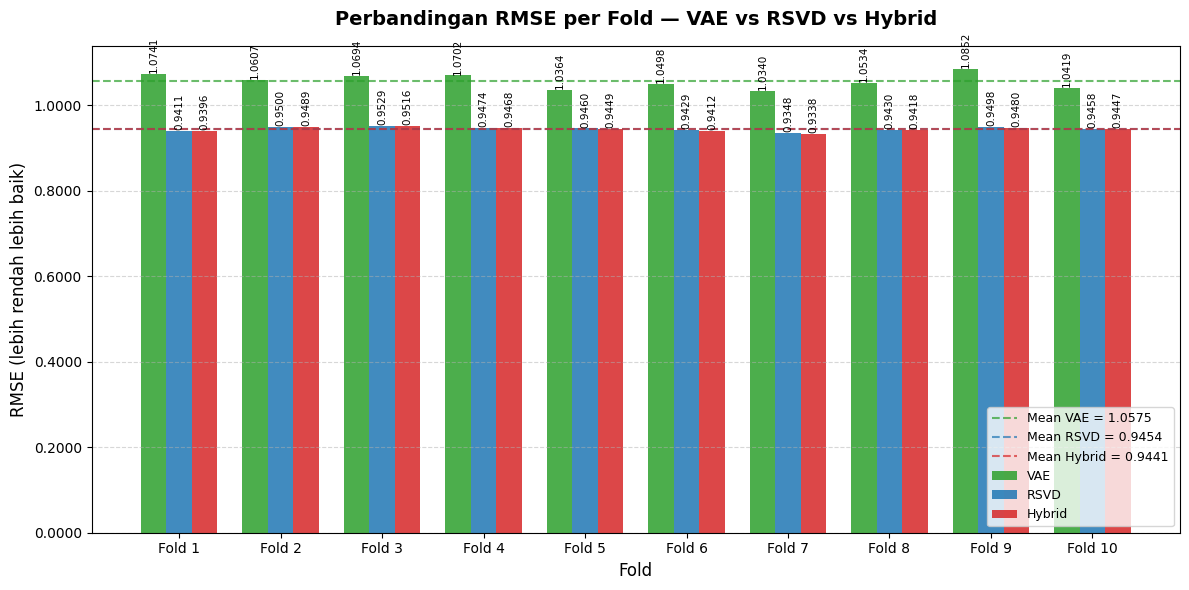

[SUCCESS] Grafik RMSE per fold tersimpan di: c:\Users\USER\Documents\Folder-Proposal\Programs\Data\CrossValidation\cv_enh_20260317_1926\cv_enh_rmse_per_fold_20260317_1926.png


In [17]:
fold_labels = [f"Fold {i}" for i in cv_results['fold']]
x_positions = np.arange(N_FOLDS)
bar_width   = 0.25

fig, ax = plt.subplots(figsize=(12, 6), dpi=100)

# Bar untuk setiap model
bars_vae    = ax.bar(x_positions - bar_width, cv_results['vae_rmse'],  bar_width, label='VAE',    color='#2ca02c', alpha=0.85)
bars_rsvd   = ax.bar(x_positions,             cv_results['rsvd_rmse'], bar_width, label='RSVD',   color='#1f77b4', alpha=0.85)
bars_hybrid = ax.bar(x_positions + bar_width, cv_results['hybrid_rmse'],bar_width,label='Hybrid', color='#d62728', alpha=0.85)

# Garis putus-putus mean untuk setiap model
ax.axhline(cv_summary['vae_rmse']['mean'],    color='#2ca02c', linestyle='--', linewidth=1.5, alpha=0.7, label=f"Mean VAE = {cv_summary['vae_rmse']['mean']:.4f}")
ax.axhline(cv_summary['rsvd_rmse']['mean'],   color='#1f77b4', linestyle='--', linewidth=1.5, alpha=0.7, label=f"Mean RSVD = {cv_summary['rsvd_rmse']['mean']:.4f}")
ax.axhline(cv_summary['hybrid_rmse']['mean'], color='#d62728', linestyle='--', linewidth=1.5, alpha=0.7, label=f"Mean Hybrid = {cv_summary['hybrid_rmse']['mean']:.4f}")

# Label nilai di atas setiap bar
for bar in [*bars_vae, *bars_rsvd, *bars_hybrid]:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2.0, height + 0.002,
            f'{height:.4f}', ha='center', va='bottom', fontsize=7.5, rotation=90)

ax.set_title('Perbandingan RMSE per Fold — VAE vs RSVD vs Hybrid', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Fold', fontsize=12)
ax.set_ylabel('RMSE (lebih rendah lebih baik)', fontsize=12)
ax.set_xticks(x_positions)
ax.set_xticklabels(fold_labels)
ax.legend(fontsize=9, loc='lower right')
ax.grid(True, axis='y', linestyle='--', alpha=0.5)
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.4f'))

plt.tight_layout()
rmse_bar_path = os.path.join(cv_run_dir, f'cv_enh_rmse_per_fold_{timestamp}.png')
plt.savefig(rmse_bar_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"[SUCCESS] Grafik RMSE per fold tersimpan di: {rmse_bar_path}")

## 2. Mean ± Std Dev

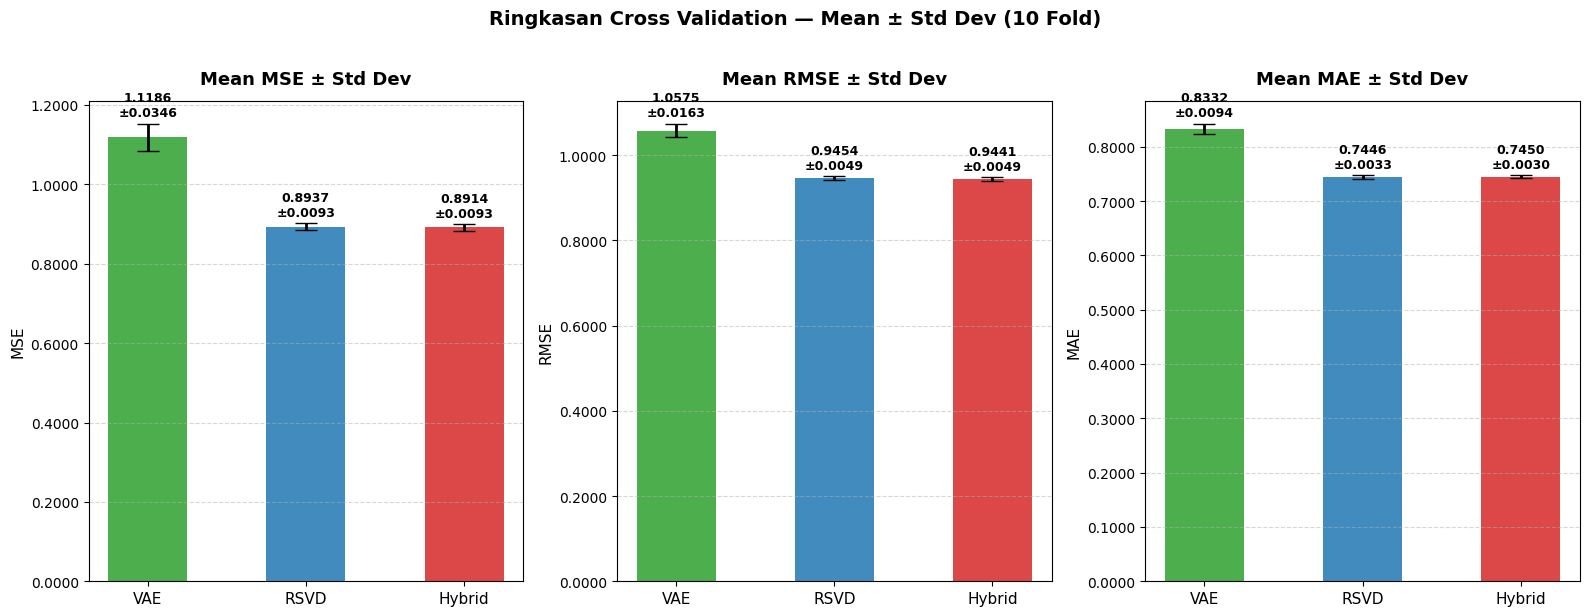

[SUCCESS] Grafik ringkasan tersimpan di: c:\Users\USER\Documents\Folder-Proposal\Programs\Data\CrossValidation\cv_enh_20260317_1926\cv_enh_summary_errorbar_20260317_1926.png


In [18]:
# Data untuk error bar chart
metric_display = ['MSE', 'RMSE', 'MAE']
metric_keys_display = ['mse', 'rmse', 'mae']

fig, axes = plt.subplots(1, 3, figsize=(16, 6), dpi=100)

model_names  = ['VAE', 'RSVD', 'Hybrid']
model_keys   = ['vae', 'rsvd', 'hybrid']
model_colors = ['#2ca02c', '#1f77b4', '#d62728']
x_pos        = np.arange(len(model_names))

for ax_idx, (metric_label, metric_key) in enumerate(zip(metric_display, metric_keys_display)):
    ax = axes[ax_idx]

    means  = [cv_summary[f'{m}_{metric_key}']['mean'] for m in model_keys]
    stds   = [cv_summary[f'{m}_{metric_key}']['std']  for m in model_keys]

    # Bar chart dengan error bar (std dev)
    bars = ax.bar(x_pos, means, color=model_colors, alpha=0.85, width=0.5,
                  yerr=stds, capsize=8, error_kw={'linewidth': 2, 'ecolor': 'black'})

    # Label nilai mean di atas bar
    for bar, mean_val, std_val in zip(bars, means, stds):
        ax.text(bar.get_x() + bar.get_width() / 2.0,
                mean_val + std_val + (mean_val * 0.01),
                f'{mean_val:.4f}\n±{std_val:.4f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

    ax.set_title(f'Mean {metric_label} ± Std Dev', fontsize=13, fontweight='bold', pad=12)
    ax.set_ylabel(metric_label, fontsize=11)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(model_names, fontsize=11)
    ax.grid(True, axis='y', linestyle='--', alpha=0.5)
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.4f'))

fig.suptitle(f'Ringkasan Cross Validation — Mean ± Std Dev ({N_FOLDS} Fold)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()

summary_plot_path = os.path.join(cv_run_dir, f'cv_enh_summary_errorbar_{timestamp}.png')
plt.savefig(summary_plot_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"[SUCCESS] Grafik ringkasan tersimpan di: {summary_plot_path}")

## 3. Metric Trend Over Folds

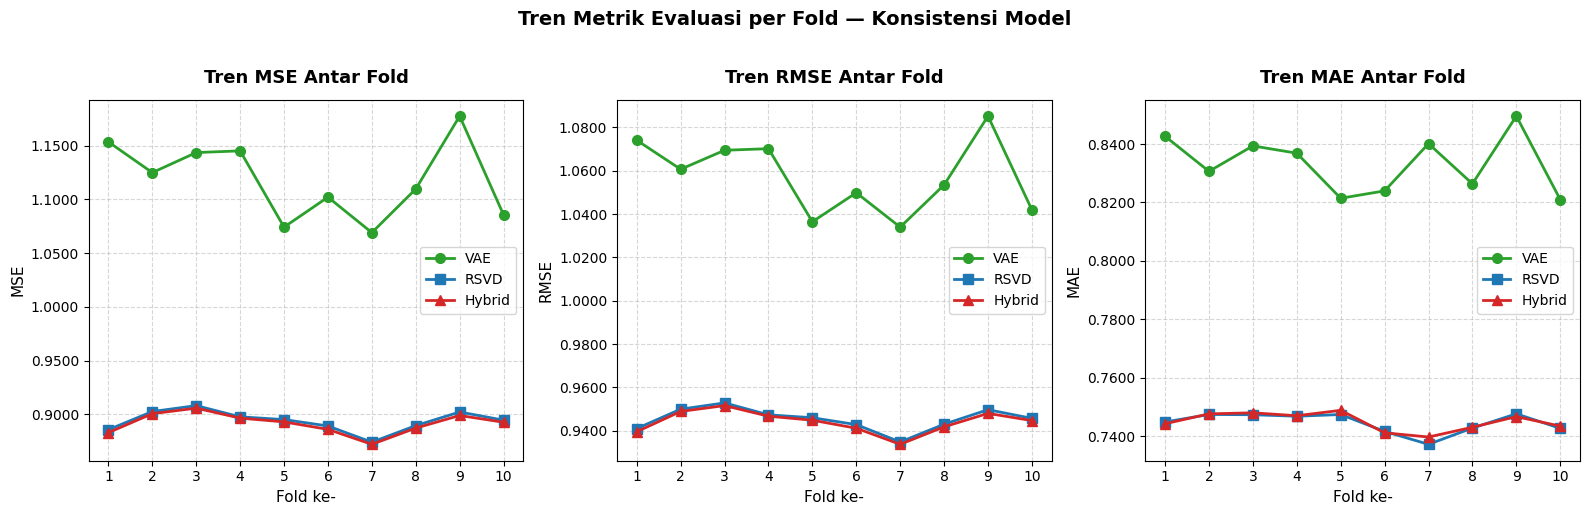

[SUCCESS] Grafik tren tersimpan di: c:\Users\USER\Documents\Folder-Proposal\Programs\Data\CrossValidation\cv_enh_20260317_1926\cv_enh_trend_per_fold_20260317_1926.png


In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), dpi=100)

fold_x = cv_results['fold']

for ax_idx, (metric_label, metric_key) in enumerate(zip(metric_display, metric_keys_display)):
    ax = axes[ax_idx]

    # Plot tren setiap model
    ax.plot(fold_x, cv_results[f'vae_{metric_key}'],    marker='o', linewidth=2,
            color='#2ca02c', label='VAE',    markersize=7)
    ax.plot(fold_x, cv_results[f'rsvd_{metric_key}'],   marker='s', linewidth=2,
            color='#1f77b4', label='RSVD',   markersize=7)
    ax.plot(fold_x, cv_results[f'hybrid_{metric_key}'], marker='^', linewidth=2,
            color='#d62728', label='Hybrid', markersize=7)

    ax.set_title(f'Tren {metric_label} Antar Fold', fontsize=13, fontweight='bold', pad=12)
    ax.set_xlabel('Fold ke-', fontsize=11)
    ax.set_ylabel(metric_label, fontsize=11)
    ax.set_xticks(fold_x)
    ax.legend(fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.4f'))

fig.suptitle('Tren Metrik Evaluasi per Fold — Konsistensi Model', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()

trend_plot_path = os.path.join(cv_run_dir, f'cv_enh_trend_per_fold_{timestamp}.png')
plt.savefig(trend_plot_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"[SUCCESS] Grafik tren tersimpan di: {trend_plot_path}")

# 11. Result Interpretation

In [20]:
# Ambil metrik ringkasan untuk interpretasi
hybrid_rmse_mean = cv_summary['hybrid_rmse']['mean']
hybrid_rmse_std  = cv_summary['hybrid_rmse']['std']
vae_rmse_mean    = cv_summary['vae_rmse']['mean']
rsvd_rmse_mean   = cv_summary['rsvd_rmse']['mean']

# Tentukan model terbaik berdasarkan mean RMSE
best_model_name = min(
    [('VAE', vae_rmse_mean), ('RSVD', rsvd_rmse_mean), ('Hybrid', hybrid_rmse_mean)],
    key=lambda x: x[1]
)[0]

# Hitung koefisien variasi (CV%) sebagai ukuran konsistensi
# CV% < 10% = sangat konsisten, 10-20% = cukup konsisten, > 20% = tidak stabil
cv_percent = (hybrid_rmse_std / hybrid_rmse_mean) * 100
consistency_label = "sangat konsisten" if cv_percent < 10 else ("cukup konsisten" if cv_percent < 20 else "perlu ditinjau ulang")

print("\n" + "="*65)
print("  INTERPRETASI HASIL CROSS VALIDATION")
print("="*65)
print(f"\n  Model terbaik berdasarkan rata-rata RMSE: {best_model_name}")
print(f"\n  Hybrid Ensemble RMSE: {hybrid_rmse_mean:.4f} ± {hybrid_rmse_std:.4f}")
print(f"  Koefisien Variasi (CV%) : {cv_percent:.2f}% → Model {consistency_label}")
print(f"\n  Rata-rata bobot ensemble terbaik per fold:")
print(f"    VAE  (alpha) = {np.mean(cv_results['best_alpha']):.2f}")
print(f"    RSVD (beta)  = {1 - np.mean(cv_results['best_alpha']):.2f}")
print("\n" + "="*65)


  INTERPRETASI HASIL CROSS VALIDATION

  Model terbaik berdasarkan rata-rata RMSE: Hybrid

  Hybrid Ensemble RMSE: 0.9441 ± 0.0049
  Koefisien Variasi (CV%) : 0.52% → Model sangat konsisten

  Rata-rata bobot ensemble terbaik per fold:
    VAE  (alpha) = 0.09
    RSVD (beta)  = 0.91



# 12. Paired t-test
Uji signifikansi statistik untuk membuktikan bahwa perbedaan performa
antar model bukan terjadi karena kebetulan semata.

**Hipotesis:**
- H0 : Tidak ada perbedaan signifikan antara kedua model (mean RMSE sama)
- H1 : Ada perbedaan signifikan antara kedua model (mean RMSE berbeda)

Kriteria penolakan H0 : p-value < 0.05 (tingkat kepercayaan 95%)

> Sel ini bisa dijalankan secara independen tanpa perlu menjalankan ulang
> seluruh CV — cukup arahkan `cv_json_path` ke file hasil CV yang sudah ada.

In [22]:
import os
import json
import numpy as np
from scipy import stats

# ============================================================
# KONFIGURASI — arahkan ke file hasil CV yang ingin dianalisis
# ============================================================
cv_output_dir = os.path.abspath(os.path.join('..', 'Data', 'CrossValidation'))

# Ganti nama file di bawah sesuai hasil CV yang ingin diuji
# Contoh: 'cv_20260313_2116/cv_results_20260313_2116.json'
CV_RESULT_FILE = 'cv_enh_20260317_1926/cv_enh_results_20260317_1926.json'

cv_json_path = os.path.join(cv_output_dir, CV_RESULT_FILE)

# Load hasil CV
try:
    with open(cv_json_path, 'r') as f:
        cv_data = json.load(f)
    print(f"[SUCCESS] Berhasil load: {cv_json_path}")
    print(f"[INFO] Timestamp  : {cv_data['timestamp']}")
    print(f"[INFO] N Folds    : {cv_data['configuration']['n_folds']}")
    print(f"[INFO] VAE params : {cv_data['configuration']['vae_params']}")
except FileNotFoundError:
    print(f"[ERROR] File tidak ditemukan: {cv_json_path}")
    print("        Pastikan CV_RESULT_FILE sudah diisi dengan nama file yang benar.")
    raise

# Ekstrak RMSE dan MAE per fold untuk setiap model
per_fold    = cv_data['per_fold_results']
N_FOLDS     = cv_data['configuration']['n_folds']
rmse_vae    = np.array(per_fold['vae_rmse'])
rmse_rsvd   = np.array(per_fold['rsvd_rmse'])
rmse_hybrid = np.array(per_fold['hybrid_rmse'])
mae_vae     = np.array(per_fold['vae_mae'])
mae_rsvd    = np.array(per_fold['rsvd_mae'])
mae_hybrid  = np.array(per_fold['hybrid_mae'])

print(f"\n[INFO] Metrik per fold dimuat:")
print(f"  {'Model':<10} | {'RMSE mean':^12} | {'RMSE std':^12} | {'MAE mean':^12} | {'MAE std':^12}")
print(f"  {'-'*10}-+-{'-'*12}-+-{'-'*12}-+-{'-'*12}-+-{'-'*12}")
print(f"  {'VAE':<10} | {rmse_vae.mean():^12.4f} | {rmse_vae.std():^12.4f} | {mae_vae.mean():^12.4f} | {mae_vae.std():^12.4f}")
print(f"  {'RSVD':<10} | {rmse_rsvd.mean():^12.4f} | {rmse_rsvd.std():^12.4f} | {mae_rsvd.mean():^12.4f} | {mae_rsvd.std():^12.4f}")
print(f"  {'Hybrid':<10} | {rmse_hybrid.mean():^12.4f} | {rmse_hybrid.std():^12.4f} | {mae_hybrid.mean():^12.4f} | {mae_hybrid.std():^12.4f}")

# ============================================================
# Paired t-test untuk RMSE
# ============================================================
t_rmse_h_r, p_rmse_h_r = stats.ttest_rel(rmse_hybrid, rmse_rsvd)
t_rmse_h_v, p_rmse_h_v = stats.ttest_rel(rmse_hybrid, rmse_vae)
t_rmse_r_v, p_rmse_r_v = stats.ttest_rel(rmse_rsvd,   rmse_vae)

# ============================================================
# Paired t-test untuk MAE
# ============================================================
t_mae_h_r, p_mae_h_r = stats.ttest_rel(mae_hybrid, mae_rsvd)
t_mae_h_v, p_mae_h_v = stats.ttest_rel(mae_hybrid, mae_vae)
t_mae_r_v, p_mae_r_v = stats.ttest_rel(mae_rsvd,   mae_vae)

# ============================================================
# Tampilkan hasil
# ============================================================
alpha = 0.05

for metric_label, comparisons in [
    ('RMSE', [
        ('Hybrid vs RSVD', t_rmse_h_r, p_rmse_h_r),
        ('Hybrid vs VAE',  t_rmse_h_v, p_rmse_h_v),
        ('RSVD vs VAE',    t_rmse_r_v, p_rmse_r_v),
    ]),
    ('MAE', [
        ('Hybrid vs RSVD', t_mae_h_r, p_mae_h_r),
        ('Hybrid vs VAE',  t_mae_h_v, p_mae_h_v),
        ('RSVD vs VAE',    t_mae_r_v, p_mae_r_v),
    ]),
]:
    print("\n" + "="*65)
    print("  PAIRED t-TEST — {} (N_FOLDS = {}, alpha = {})".format(metric_label, N_FOLDS, alpha))
    print("="*65)
    print(f"  {'Perbandingan':<25} | {'t-statistic':^14} | {'p-value':^12} | {'Kesimpulan'}")
    print(f"  {'-'*25}-+-{'-'*14}-+-{'-'*12}-+-{'-'*20}")
    for label, t_stat, p_val in comparisons:
        kesimpulan = 'Signifikan *' if p_val < alpha else 'Tidak Signifikan'
        print(f"  {label:<25} | {t_stat:^14.4f} | {p_val:^12.4f} | {kesimpulan}")

print("\n  Catatan: * = H0 ditolak, perbedaan signifikan pada alpha = 0.05")
print("           t-statistic negatif = model pertama memiliki nilai lebih rendah (lebih baik)")
print("="*65)

# Simpan hasil t-test ke file JSON CV yang sama
ttest_results = {
    'alpha'   : alpha,
    'n_folds' : N_FOLDS,
    'rmse': {
        'hybrid_vs_rsvd' : {'t_statistic': float(t_rmse_h_r), 'p_value': float(p_rmse_h_r), 'significant': bool(p_rmse_h_r < alpha)},
        'hybrid_vs_vae'  : {'t_statistic': float(t_rmse_h_v), 'p_value': float(p_rmse_h_v), 'significant': bool(p_rmse_h_v < alpha)},
        'rsvd_vs_vae'    : {'t_statistic': float(t_rmse_r_v), 'p_value': float(p_rmse_r_v), 'significant': bool(p_rmse_r_v < alpha)},
    },
    'mae': {
        'hybrid_vs_rsvd' : {'t_statistic': float(t_mae_h_r), 'p_value': float(p_mae_h_r), 'significant': bool(p_mae_h_r < alpha)},
        'hybrid_vs_vae'  : {'t_statistic': float(t_mae_h_v), 'p_value': float(p_mae_h_v), 'significant': bool(p_mae_h_v < alpha)},
        'rsvd_vs_vae'    : {'t_statistic': float(t_mae_r_v), 'p_value': float(p_mae_r_v), 'significant': bool(p_mae_r_v < alpha)},
    },
}

cv_data['paired_ttest'] = ttest_results

with open(cv_json_path, 'w') as f:
    json.dump(cv_data, f, indent=4)

print(f"\n[SUCCESS] Hasil t-test ditambahkan ke: {cv_json_path}")


[SUCCESS] Berhasil load: c:\Users\USER\Documents\Folder-Proposal\Programs\Data\CrossValidation\cv_enh_20260317_1926/cv_enh_results_20260317_1926.json
[INFO] Timestamp  : 20260317_1926
[INFO] N Folds    : 10
[INFO] VAE params : {'latent_dim': 200, 'learning_rate': 0.005, 'batch_size': 128, 'dropout_rate': 0.4, 'beta': 0.1, 'cycle_epochs': 15, 'hidden_dims': [512, 256, 128]}

[INFO] Metrik per fold dimuat:
  Model      |  RMSE mean   |   RMSE std   |   MAE mean   |   MAE std   
  -----------+--------------+--------------+--------------+-------------
  VAE        |    1.0575    |    0.0163    |    0.8332    |    0.0094   
  RSVD       |    0.9454    |    0.0049    |    0.7446    |    0.0033   
  Hybrid     |    0.9441    |    0.0049    |    0.7450    |    0.0030   

  PAIRED t-TEST — RMSE (N_FOLDS = 10, alpha = 0.05)
  Perbandingan              |  t-statistic   |   p-value    | Kesimpulan
  --------------------------+----------------+--------------+---------------------
  Hybrid vs RSVD  